# Task 2: Data Cleaning on Messy HR Dataset
Objective: Take a deliberately messy dataset and systematically clean and standardize it for analysis.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Data Loading and Initial Quality Report
First, I loaded the dirty dataset and inspect its structure, null values, and duplicates.

In [ ]:
df = pd.read_csv('../data/messy_HR_data.csv')
print("Shape of dataset:", df.shape)
print("\nData Quality Report - Nulls per column:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Shape of dataset: (1000, 10)

Data Quality Report - Nulls per column:
Name                   0
Age                  159
Salary                 0
Gender                 0
Department             0
Position               0
Joining Date           0
Performance Score      0
Email                390
Phone Number         185
dtype: int64

Duplicate rows: 0


In [ ]:
df.head()

,Name,Age,Salary,Gender,Department,Position,Joining Date,Performance Score,Email,Phone Number
0,grace,25,50000,Male,HR,Manager,"April 5, 2018",D,email@example.com,NaN
1,david,NaN,65000,Female,Finance,Director,2020/02/20,F,user@domain.com,123-456-7890
2,hannah,35,SIXTY THOUSAND,Female,Sales,Director,01/15/2020,C,email@example.com,098-765-4321
3,eve,NaN,50000,Female,IT,Manager,"April 5, 2018",A,name@company.org,
4,grace,NaN,NAN,Female,Finance,Manager,01/15/2020,F,name@company.org,098-765-4321


### 2. Duplicate Removal
I dropped any duplicated rows to maintain unique records.

In [ ]:
df = df.drop_duplicates()
print("Rows remaining after dropping duplicates:", df.shape[0])

Rows remaining after dropping duplicates: 1000


### 3. Data Standardization and Formatting
I standardized names to Title Case, dates to a uniform date format, and clean the messy salary column by mapping text numbers to digits and casting to numeric.

In [ ]:
# Standardize Name case
df['Name'] = df['Name'].astype(str).str.title()

# Clean Salary values
df['Salary'] = df['Salary'].astype(str).str.lower().str.strip()
salary_map = {
    'sixty thousand': '60000',
    'seventy-five thousand': '75000',
    'fifty-five thousand': '55000',
    'forty-five thousand': '45000',
    'eighty thousand': '80000',
    'nan': 'nan'
}
df['Salary'] = df['Salary'].replace(salary_map)
df['Salary'] = pd.to_numeric(df['Salary'], errors='coerce')

# Clean Age
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

# Parse mixed Joining Date formats
df['Joining Date'] = pd.to_datetime(df['Joining Date'], format='mixed')

### 4. Handling Missing Data (Imputation)
I imputed numeric columns (`Age`, `Salary`) with their respective medians, and fill missing `Email` and `Phone Number` values with placeholders to keep all rows.

In [ ]:
# Impute numeric columns with median
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Salary'] = df['Salary'].fillna(df['Salary'].median())

# Fill missing categories with placeholders
df['Email'] = df['Email'].fillna('missing@company.com')
df['Phone Number'] = df['Phone Number'].fillna('Unknown')

### 5. Outlier Detection (IQR Method)
I used the Interquartile Range (IQR) method to find outliers in numerical columns.

Number of outliers in Age: 332


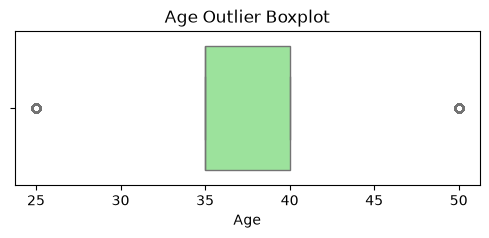

Number of outliers in Salary: 0


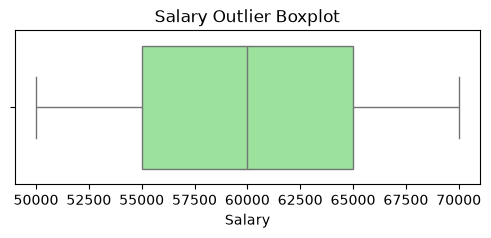

In [ ]:
for col in ['Age', 'Salary']:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"Number of outliers in {col}: {len(outliers)}")
    
    # Visualizing outliers using box plots
    plt.figure(figsize=(6, 2))
    sns.boxplot(x=df[col], color='lightgreen')
    plt.title(f'{col} Outlier Boxplot')
    plt.show()

### 6. Before vs. After Summary
Next, I checked the state of the final cleaned dataset.

In [ ]:
print("Remaining nulls:")
print(df.isnull().sum())
print("\nRemaining duplicates:", df.duplicated().sum())
print("\nData Types:")
print(df.dtypes)

Remaining nulls:
Name                 0
Age                  0
Salary               0
Gender               0
Department           0
Position             0
Joining Date         0
Performance Score    0
Email                0
Phone Number         0
dtype: int64

Remaining duplicates: 0

Data Types:
Name                            str
Age                         float64
Salary                      float64
Gender                          str
Department                      str
Position                        str
Joining Date         datetime64[us]
Performance Score               str
Email                           str
Phone Number                    str
dtype: object


### 7. Export Cleaned Dataset
I saved the final cleaned version to a new CSV file.

In [ ]:
output_path = '../data/cleaned_HR_data.csv'
df.to_csv(output_path, index=False)
print(f"Cleaned dataset saved successfully to {output_path}!")

Cleaned dataset saved successfully to ../data/cleaned_HR_data.csv!


### Conclusion
I successfully cleaned the dataset and got it ready for analysis. Here is a summary of what I did:

1. I used the median to fill in missing Ages and Salaries. This way I didn't have to delete the rows and it didn't mess up the averages.
2. I fixed the messy date formats by converting them all into proper datetime objects.
3. For missing emails and phone numbers, I just put in a placeholder text so I wouldn't lose the rest of the data in those rows.